<a href="https://colab.research.google.com/github/vivekjain060305-coder/Wine_Quality_Prerdiction/blob/main/Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Naman Udapure

CS23093

Saving wine-quality-white-and-red.csv to wine-quality-white-and-red (1).csv
Accuracy: 83.23076923076923
Precision Score: 0.6605504587155964
F1 Score: 0.39779005524861877
AUC Score: 0.8376860670992976


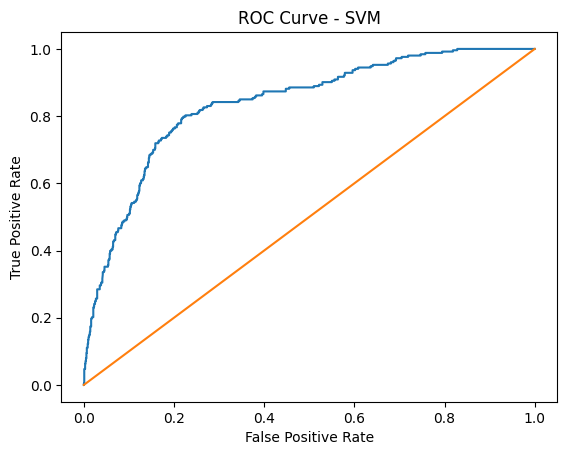

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


# Step 2: Upload dataset
from google.colab import files
uploaded = files.upload()

# Step 3: Load dataset
df = pd.read_csv("wine-quality-white-and-red.csv")

# Step 4: Convert wine quality into binary classification
df["quality_label"] = (df["quality"] >= 7).astype(int)

# Step 5: Define features and target
X = df.drop(["quality","quality_label"], axis=1)
y = df["quality_label"]

# One-hot encode the 'type' column
X = pd.get_dummies(X, columns=['type'], drop_first=True) # drop_first avoids multicollinearity

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Feature scaling (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 8: Train SVM model
model = SVC(kernel='rbf', probability=True, random_state=42)
model.fit(X_train, y_train)

# Step 9: Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

# Step 10: Evaluation metrics
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision Score:", precision)
print("F1 Score:", f1)

# Step 11: ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

print("AUC Score:", auc_score)

# Step 12: Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.show()